# Colour Space & Algorithm Exploration

## Context

In the previous workbook we discovered by plotting 3D scatter plots of pixels in various colour spaces, that RGB produced the least visually clear clusters, LAB produced plots with most colours clumped towards the center, HSV showed the most visually distinct clusters, with hue showing the clearest separation of values. 

We've still not formally tested  whether any of this translates into better clustering performance. 

## Objective

The purpose of this workbook is to figure out which combination of colour space and clustering algorithm best separates colour families in images. 

We'll test 4 different colour spaces; HSV, LAB, RGB, and Hue (isolated from Saturation and Value in HSV colour space). We'll also test 3 different clustering algorithms; K-Means, GMM, and Agglomerative. 

The results will be used to justify the methodology choice for the final scoring pipeline.

## Imports & Configuration

In [1]:
import sys
import os
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import time
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from skimage import color


sys.path.append(os.path.abspath('..'))

from src.preprocessing import get_image_data
from src.preprocessing import to_rgb_pixels
from src.preprocessing import to_hsv_pixels
from src.preprocessing import to_lab_pixels
from src.clustering import cluster_pixels
from src.visualisation import plot_image
from src.visualisation import plot_percentages
from src.visualisation import plot_hues
from src.clustering import cluster_pixels
from src.scoring import get_scores

In [2]:
IMAGE_SOURCES = []
with open('../data/image_sources.txt', 'r') as f:
    IMAGE_SOURCES = [line.strip() for line in f if line.strip()]

def generate_random_image(size):
    height = int(np.ceil(np.sqrt(size)))
    width = height
    return Image.fromarray(np.random.randint(0, 255, (height, width, 3), dtype=np.uint8))

## Runtime and Scalability Analysis

In order to properly use each clustering algorithm we'll need to decide sensible and safe limits for the number of pixels we can cluster. 

We'll do this by plotting runtime against pixel count with a complexity curve to help draw conclusions on safe pixel counts. 

### Functions

In [3]:
def linear(n, a, b):
    return a * n + b

def predict_linear(y, a, b):
    return (y - b) / a

def n2_logn(n, a, b):
    return a * (n**2 * np.log(n)) + b

def predict_n2_logn(y, a, b):
    f = lambda n: n2_logn(n, a, b) - y
    return brentq(f, 1, 1_000_000)

### K-Means

Start by testing a range of sizes. 

In [4]:
sizes = [10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000, 10_000_000]
pixel_counts = []
times = []

# Warmup run
warmup_img = generate_random_image(1000)
warmup_pixels = np.array(warmup_img).reshape(-1, 3)
cluster_pixels(warmup_pixels, algorithm="kmeans")

for size in sizes:
    img = generate_random_image(size)
    pixels = to_rgb_pixels(img)
    start = time.time()
    labels, centers = cluster_pixels(pixels, algorithm="kmeans")
    pixel_count = len(pixels)
    pixel_counts.append(pixel_count)
    elapsed = time.time() - start
    times.append(elapsed)
    print(f"Pixels: {pixel_count}, Runtime: {elapsed:.2f}s")

Pixels: 10000, Runtime: 0.04s
Pixels: 50176, Runtime: 0.09s
Pixels: 100489, Runtime: 0.18s
Pixels: 501264, Runtime: 0.72s
Pixels: 1000000, Runtime: 1.36s
Pixels: 5004169, Runtime: 7.13s
Pixels: 10004569, Runtime: 11.78s


Fit those tested runtimes against the hypothetical time complexity. 

In [5]:
popt_kmeans, _ = curve_fit(linear, pixel_counts, times)

Plot both the observed runtimes, and the linear fit. 

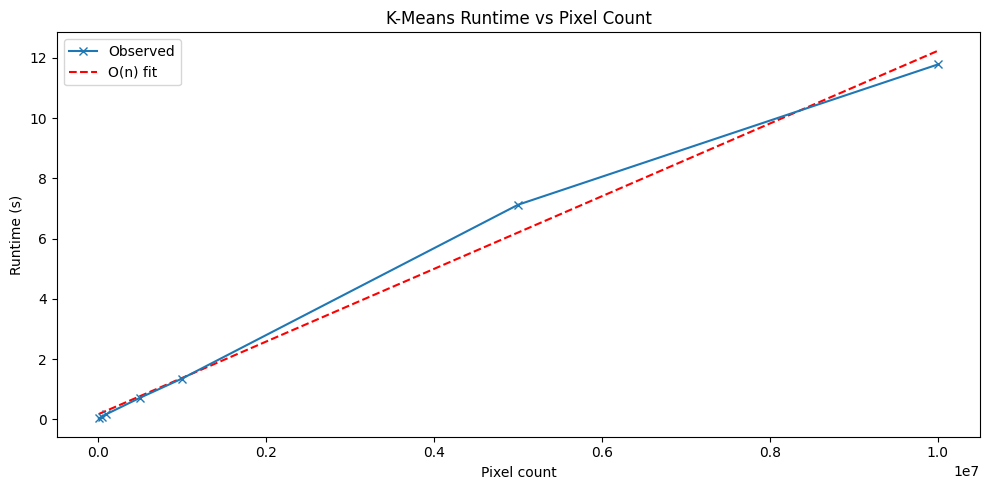

In [6]:
x_range = np.linspace(min(pixel_counts), max(pixel_counts), 500)
y_fit = linear(x_range, popt_kmeans[0], popt_kmeans[1])

plt.figure(figsize=(10, 5))
plt.plot(pixel_counts, times, marker='x', label='Observed', zorder=5)
plt.plot(x_range, y_fit, linestyle='--', label=f'O(n) fit', color='red')
plt.xlabel('Pixel count')
plt.ylabel('Runtime (s)')
plt.title('K-Means Runtime vs Pixel Count')
plt.legend()
plt.tight_layout()
plt.show()

We can see that it's good fit, so we use the inverse of the linear equation to get the maximum pixels based on a maximum runtime. 

In [7]:
target_time = 1
a, b = popt_kmeans
estimated_pixels = predict_linear(target_time, a, b)
print(f"Max pixels for {target_time}s runtime: {int(estimated_pixels):,}")
target_time = 10
a, b = popt_kmeans
estimated_pixels = predict_linear(target_time, a, b)
print(f"Max pixels for {target_time}s runtime: {int(estimated_pixels):,}")

Max pixels for 1s runtime: 688,606
Max pixels for 10s runtime: 8,149,003


### GMM

We repeat the same process as before. 

In [8]:
sizes = [10_000, 50_000, 100_000, 500_000, 1_000_000, 5_000_000]
pixel_counts = []
times = []

# Warmup run
warmup_img = generate_random_image(1000)
warmup_pixels = np.array(warmup_img).reshape(-1, 3)
cluster_pixels(warmup_pixels, algorithm="gmm")

for size in sizes:
    img = generate_random_image(size)
    pixels = to_rgb_pixels(img)
    start = time.time()
    labels, centers = cluster_pixels(pixels, algorithm="gmm")
    pixel_count = len(pixels)
    pixel_counts.append(pixel_count)
    elapsed = time.time() - start
    times.append(elapsed)
    print(f"Pixels: {pixel_count}, Runtime: {elapsed:.2f}s")

Pixels: 10000, Runtime: 0.13s
Pixels: 50176, Runtime: 0.17s
Pixels: 100489, Runtime: 0.28s
Pixels: 501264, Runtime: 1.34s
Pixels: 1000000, Runtime: 2.74s
Pixels: 5004169, Runtime: 13.89s


In [9]:
popt_gmm, _ = curve_fit(linear, pixel_counts, times)

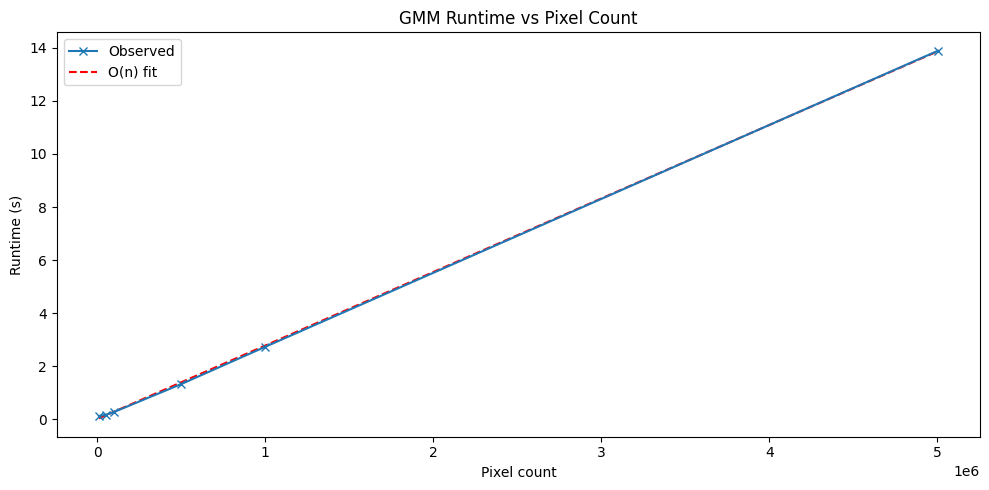

In [10]:
x_range = np.linspace(min(pixel_counts), max(pixel_counts), 500)
y_fit = linear(x_range, popt_gmm[0], popt_gmm[1])

plt.figure(figsize=(10, 5))
plt.plot(pixel_counts, times, marker='x', label='Observed', zorder=5)
plt.plot(x_range, y_fit, linestyle='--', label=f'O(n) fit', color='red')
plt.xlabel('Pixel count')
plt.ylabel('Runtime (s)')
plt.title('GMM Runtime vs Pixel Count')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
target_time = 1
a, b = popt_gmm
estimated_pixels = predict_linear(target_time, a, b)
print(f"Max pixels for {target_time}s runtime: {int(estimated_pixels):,}")
target_time = 10
a, b = popt_gmm
estimated_pixels = predict_linear(target_time, a, b)
print(f"Max pixels for {target_time}s runtime: {int(estimated_pixels):,}")

Max pixels for 1s runtime: 355,712
Max pixels for 10s runtime: 3,606,402


### Agglomerative

We repeat the same process as before. 

In [12]:
sizes = [100, 500, 1_000, 2_000, 5_000, 10_000, 15_000, 20_000]
pixel_counts = []
times = []

# Warmup run
warmup_img = generate_random_image(1000)
warmup_pixels = np.array(warmup_img).reshape(-1, 3)
cluster_pixels(warmup_pixels, algorithm="agglomerative")

for size in sizes:
    img = generate_random_image(size)
    pixels = to_rgb_pixels(img)
    start = time.time()
    labels, centers = cluster_pixels(pixels, algorithm="agglomerative")
    pixel_count = len(pixels)
    pixel_counts.append(pixel_count)
    elapsed = time.time() - start
    times.append(elapsed)
    print(f"Pixels: {pixel_count}, Runtime: {elapsed:.2f}s")

Pixels: 100, Runtime: 0.00s
Pixels: 529, Runtime: 0.01s
Pixels: 1024, Runtime: 0.01s
Pixels: 2025, Runtime: 0.06s
Pixels: 5041, Runtime: 0.51s
Pixels: 10000, Runtime: 2.16s
Pixels: 15129, Runtime: 5.91s
Pixels: 20164, Runtime: 10.44s


We plot with n2_logn instead of linear. 

In [13]:
popt_agg, _ = curve_fit(n2_logn, pixel_counts, times)

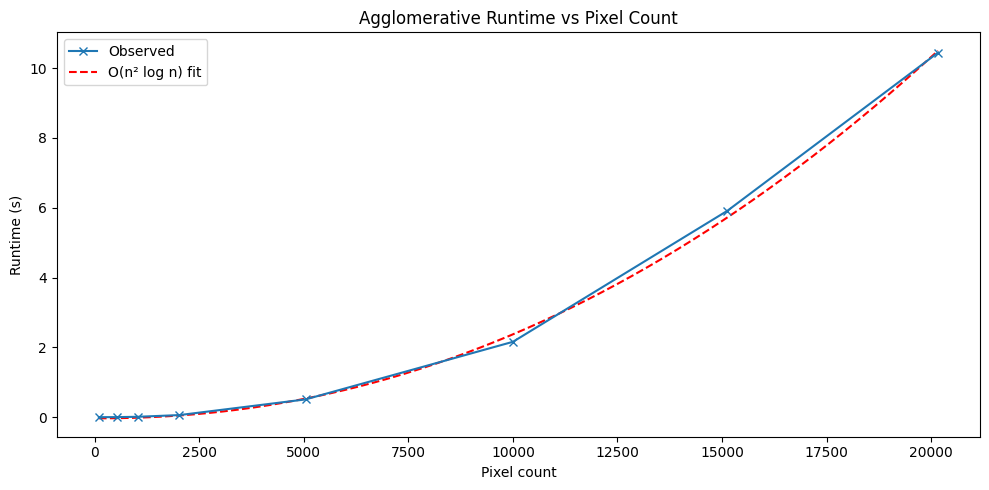

In [14]:
x_range = np.linspace(min(pixel_counts), max(pixel_counts), 500)
y_fit = n2_logn(x_range, popt_agg[0], popt_agg[1])

plt.figure(figsize=(10, 5))
plt.plot(pixel_counts, times, marker='x', label='Observed', zorder=5)
plt.plot(x_range, y_fit, linestyle='--', label=f'O(n² log n) fit', color='red')
plt.xlabel('Pixel count')
plt.ylabel('Runtime (s)')
plt.title('Agglomerative Runtime vs Pixel Count')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
target_time = 1
a, b = popt_agg
estimated_pixels = predict_n2_logn(target_time, a, b)
print(f"Max pixels for {target_time}s runtime: {int(estimated_pixels):,}")
target_time = 10
a, b = popt_agg
estimated_pixels = predict_n2_logn(target_time, a, b)
print(f"Max pixels for {target_time}s runtime: {int(estimated_pixels):,}")

Max pixels for 1s runtime: 6,692
Max pixels for 10s runtime: 19,706


### Estimating Time

We will need to do a total of 192 tests. 3 algorithms, 4 colour spaces, and 16 images. 

In order to achieve a sensible runtime of around 10 mins we'll need each of these tests to take around 3 seconds. 

$$\frac{60*10}{3*4*16} = 3.125 \text{ seconds per test}$$

In [16]:
SAMPLE_SIZES = {
    'kmeans': int(predict_linear(3.125, *popt_kmeans)),
    'gmm': int(predict_linear(3.125, *popt_gmm)),
    'agglomerative': int(predict_n2_logn(3.125, *popt_agg))
}
for key, value in SAMPLE_SIZES.items():
    print(key, value)

kmeans 2450089
gmm 1123236
agglomerative 11373


Because one of the downsides of the agglomerative algorithm is it's time complexity, it's not fair on the other 2 algorithms to downsample their images to the same size that's needed for agglomerative clustering. 

In [17]:
images = [get_image_data(source) for source in IMAGE_SOURCES]
for img in images:
    pixels = to_rgb_pixels(img)
    print(len(pixels))

1443051
898614
2379416
2485197
2483910
2325620
2485197
1441089
2485197
955200
1266000
326900
106533
614400
756000
727489


Most of the raw images are smaller than the sample sizes for K-Means meaning they wont need to be downsized. Many of the images will need to be downscaled for GMM, and every image will need to be significantly downsized for Agglomerative. 

## Clustering Comparison

In [18]:
def hue_transform_full(pixels_hsv):
    hue = pixels_hsv[:, 0]
    cos_hue = np.cos(2 * np.pi * hue)
    sin_hue = np.sin(2 * np.pi * hue)
    s = pixels_hsv[:, 1]
    v = pixels_hsv[:, 2]
    return np.stack([cos_hue, sin_hue, s, v], axis=1)

In [19]:
def hue_transform_full_inverse(pixels_transformed):
    cos_hue = pixels_transformed[:, 0]
    sin_hue = pixels_transformed[:, 1]
    hue = np.arctan2(sin_hue, cos_hue) / (2 * np.pi) % 1.0
    s = pixels_transformed[:, 2]
    v = pixels_transformed[:, 3]
    return np.stack([hue, s, v], axis=1)

In [20]:
scores = {}
for algorithm in ('kmeans', 'gmm', 'agglomerative'):
    scores[algorithm] = {}
    for index, source in enumerate(IMAGE_SOURCES):
        print(f"{algorithm} - image {index+1}/{len(IMAGE_SOURCES)}")
        scores[algorithm][index] = {}
        img = get_image_data(source, SAMPLE_SIZES[algorithm])
        
        # RGB
        pixels_rgb = to_rgb_pixels(img)
        labels, centers_rgb = cluster_pixels(pixels_rgb, algorithm=algorithm)
        scores[algorithm][index]['rgb'] = get_scores(pixels_rgb, labels, centers_rgb)

        # LAB
        pixels_lab = to_lab_pixels(img)
        labels, centers_lab = cluster_pixels(pixels_lab, algorithm=algorithm)
        centers_rgb = color.lab2rgb(centers_lab)
        scores[algorithm][index]['lab'] = get_scores(pixels_lab, labels, centers_rgb)
        
        # HSV
        pixels_hsv = to_hsv_pixels(img)
        pixels_hsv_transformed = hue_transform_full(pixels_hsv)
        labels, centers_hsv = cluster_pixels(pixels_hsv_transformed, algorithm=algorithm)
        centers_rgb = color.hsv2rgb(hue_transform_full_inverse(centers_hsv))
        scores[algorithm][index]['hsv'] = get_scores(pixels_hsv_transformed, labels, centers_rgb)
        
        # Hue
        pixels_hue = np.hstack([pixels_hsv_transformed[:, :2], np.ones((len(pixels_hsv_transformed), 2))])
        labels, centers_hue = cluster_pixels(pixels_hue, algorithm=algorithm)
        centers_rgb = color.hsv2rgb(hue_transform_full_inverse(centers_hue))
        scores[algorithm][index]['hue'] = get_scores(pixels_hue, labels, centers_rgb)


kmeans - image 1/16
kmeans - image 2/16
kmeans - image 3/16
kmeans - image 4/16
kmeans - image 5/16
kmeans - image 6/16
kmeans - image 7/16
kmeans - image 8/16
kmeans - image 9/16
kmeans - image 10/16
kmeans - image 11/16
kmeans - image 12/16
kmeans - image 13/16
kmeans - image 14/16
kmeans - image 15/16
kmeans - image 16/16
gmm - image 1/16
gmm - image 2/16
gmm - image 3/16
gmm - image 4/16
gmm - image 5/16
gmm - image 6/16
gmm - image 7/16
gmm - image 8/16
gmm - image 9/16
gmm - image 10/16
gmm - image 11/16
gmm - image 12/16
gmm - image 13/16
gmm - image 14/16
gmm - image 15/16
gmm - image 16/16
agglomerative - image 1/16
agglomerative - image 2/16
agglomerative - image 3/16
agglomerative - image 4/16
agglomerative - image 5/16
agglomerative - image 6/16
agglomerative - image 7/16
agglomerative - image 8/16
agglomerative - image 9/16
agglomerative - image 10/16
agglomerative - image 11/16
agglomerative - image 12/16
agglomerative - image 13/16
agglomerative - image 14/16
agglomerati

In [21]:
scores

{'kmeans': {0: {'rgb': {'silhouette': 0.46346646547317505,
    'davies_bouldin': 0.6895935609518373,
    'calinski_harabasz': 2433983.5,
    'ratio_score': 0.7752650460725227,
    'harmony_scores': {'triadic': 0.02038407325744629,
     'analogous': 0.7703840732574463,
     'split_complementary': 0.02038407325744629,
     'complementary_accent': 0.4370507001876831,
     'clash': 0.2703840732574463,
     'accented_analogous': 0.4370507001876831,
     'near_complementary': 0.4787173867225647,
     'best_scheme': 'analogous',
     'best_score': 0.7703840732574463}},
   'lab': {'silhouette': 0.3490162789821625,
    'davies_bouldin': 1.0072189255475739,
    'calinski_harabasz': 1295611.375,
    'ratio_score': 0.650251619658626,
    'harmony_scores': {'triadic': 0.03432118892669678,
     'analogous': 0.7843211889266968,
     'split_complementary': 0.03432118892669678,
     'complementary_accent': 0.4509878158569336,
     'clash': 0.2843211889266968,
     'accented_analogous': 0.45098781585693

# g

In [22]:
IMAGE_SOURCES = []
with open('../data/image_sources.txt', 'r') as f:
    IMAGE_SOURCES = [line.strip() for line in f if line.strip()]

MAX_PIXELS = 100_000_000
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [23]:
images = [get_image_data(source, MAX_PIXELS) for source in IMAGE_SOURCES]

In [24]:
for img in images:
    arr = np.array(img)
    pixels = arr.reshape(-1,3)
    print(len(pixels))

1443051
898614
2379416
2485197
2483910
2325620
2485197
1441089
2485197
955200
1266000
326900
106533
614400
756000
727489


In [25]:
"""
for img in images:
    arr = np.array(img)
    pixels = arr.reshape(-1,3)
    labels, centers = cluster_pixels(pixels, algorithm="kmeans")
    centers = np.uint8(centers)
    counts = np.bincount(labels)
    pixels_clustered = centers[labels].reshape(img.size[1], img.size[0],3)
    
    fig = plt.figure(figsize=(10, 10))
    
    ax1 = fig.add_subplot(221)
    plot_image(ax1, img, title="Raw")
    ax2 = fig.add_subplot(222)
    plot_image(ax2, pixels_clustered, title="Clustered")
    ax3 = fig.add_subplot(223)
    plot_percentages(ax3, counts, centers)
    ax4 = fig.add_subplot(224, projection='polar')
    plot_hues(ax4, centers)
    plt.show()
"""

'\nfor img in images:\n    arr = np.array(img)\n    pixels = arr.reshape(-1,3)\n    labels, centers = cluster_pixels(pixels, algorithm="kmeans")\n    centers = np.uint8(centers)\n    counts = np.bincount(labels)\n    pixels_clustered = centers[labels].reshape(img.size[1], img.size[0],3)\n    \n    fig = plt.figure(figsize=(10, 10))\n    \n    ax1 = fig.add_subplot(221)\n    plot_image(ax1, img, title="Raw")\n    ax2 = fig.add_subplot(222)\n    plot_image(ax2, pixels_clustered, title="Clustered")\n    ax3 = fig.add_subplot(223)\n    plot_percentages(ax3, counts, centers)\n    ax4 = fig.add_subplot(224, projection=\'polar\')\n    plot_hues(ax4, centers)\n    plt.show()\n'